# SIS Project: Performance vs Fan Attendance in the Premier League

**Course:** Data Collection & Preparation  
**Season:** 2024–2025  
**League:** English Premier League

## Project Overview

This project investigates the relationship between football club performance and fan attendance in the English Premier League during the 2024–2025 season.

The main goal is to explore whether clubs with higher average home attendance also achieve better results in the league.

## Research Questions

1. Which Premier League clubs have the highest average home attendance?
2. Do clubs with higher attendance earn more league points?
3. Is there a relationship between fan attendance and the number of wins?
4. How does attendance relate to a club's final league position?

## Data Sources

1. **Football-data.org API:** League standings, points, wins, draws, losses, and goals.
2. **Wikipedia (Web Scraping):** Average home attendance for each Premier League club in the 2024–2025 season.

## Tools and Libraries

- Python
- pandas
- requests
- BeautifulSoup
- Matplotlib
- Seaborn

## Project Workflow

1. Collect data from the API.
2. Scrape attendance data from Wikipedia.
3. Clean and prepare both datasets.
4. Merge the datasets using football club names.
5. Perform exploratory data analysis.
6. Create visualizations.
7. Analyze correlations and summarize the findings.

## 1. Importing Libraries

First, we install and import the necessary Python libraries for data collection, processing, and visualization.

In [1]:
%pip install pandas requests beautifulsoup4 matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns
import re
from urllib.robotparser import RobotFileParser
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Data Collection from API

In this section, we collect Premier League performance statistics using the Football-data.org REST API.

The API provides information about each club, including:

- League position
- Matches played
- Wins, draws, and losses
- Goals scored and conceded
- Goal difference
- Total league points

We request data for the 2024–2025 season using the `season=2024` parameter.

If historical standings are unavailable, we attempt to retrieve the season's match results and calculate the same performance statistics.

In [3]:
from getpass import getpass

API_KEY = getpass("Enter your Football-data.org API key: ")

SEASON = 2024
BASE_URL = "https://api.football-data.org/v4/competitions/PL"

headers = {
    "X-Auth-Token": API_KEY
}

print("API configuration completed.")

Enter your Football-data.org API key:  ········


API configuration completed.


In [4]:
standings_url = f"{BASE_URL}/standings"

response = requests.get(
    standings_url,
    headers=headers,
    params={"season": SEASON},
    timeout=30
)

print("API status code:", response.status_code)
print("Requested URL:", response.url)

if response.status_code == 200:
    standings_data = response.json()

    season_start = standings_data.get("season", {}).get("startDate", "")

    if not season_start.startswith(str(SEASON)):
        raise ValueError("API returned data for the wrong season.")

    print("Standings data collected successfully!")
else:
    standings_data = None
    print("Historical standings unavailable. Match data will be checked.")
    print(response.text[:300])

API status code: 200
Requested URL: https://api.football-data.org/v4/competitions/PL/standings?season=2024
Standings data collected successfully!


In [5]:
if standings_data is not None:

    total_table = next(
        (
            item["table"]
            for item in standings_data["standings"]
            if item.get("type") == "TOTAL"
        ),
        None
    )

    if total_table is None:
        raise ValueError("TOTAL standings table was not found.")

    teams_data = []

    for item in total_table:
        teams_data.append({
            "team": item["team"]["name"],
            "position": item["position"],
            "played": item["playedGames"],
            "wins": item["won"],
            "draws": item["draw"],
            "losses": item["lost"],
            "goals_for": item["goalsFor"],
            "goals_against": item["goalsAgainst"],
            "goal_difference": item["goalDifference"],
            "points": item["points"]
        })

    api_df = pd.DataFrame(teams_data)

    print("Performance data extracted from standings.")

else:
    print("Trying the matches endpoint...")

    matches_response = requests.get(
        f"{BASE_URL}/matches",
        headers=headers,
        params={"season": SEASON},
        timeout=30
    )

    print("Matches API status:", matches_response.status_code)

    if matches_response.status_code != 200:
        raise RuntimeError(
            "Historical data is not available with this API key. "
            "Check access to season 2024. "
            f"HTTP status: {matches_response.status_code}"
        )

    matches_data = matches_response.json()
    matches = matches_data.get("matches", [])

    finished_matches = [
        match for match in matches
        if match["status"] == "FINISHED"
        and match.get("score", {}).get("fullTime", {}).get("home") is not None
        and match.get("score", {}).get("fullTime", {}).get("away") is not None
    ]

    if len(finished_matches) != 380:
        raise ValueError(
            f"Expected 380 finished matches, got {len(finished_matches)}. "
            "The season data may be incomplete."
        )

    stats = {}

    for match in finished_matches:
        home = match["homeTeam"]
        away = match["awayTeam"]

        home_id = home["id"]
        away_id = away["id"]

        home_goals = match["score"]["fullTime"]["home"]
        away_goals = match["score"]["fullTime"]["away"]

        for team in [home, away]:
            team_id = team["id"]

            if team_id not in stats:
                stats[team_id] = {
                    "team": team["name"],
                    "played": 0,
                    "wins": 0,
                    "draws": 0,
                    "losses": 0,
                    "goals_for": 0,
                    "goals_against": 0,
                    "points": 0
                }

        stats[home_id]["played"] += 1
        stats[away_id]["played"] += 1

        stats[home_id]["goals_for"] += home_goals
        stats[home_id]["goals_against"] += away_goals

        stats[away_id]["goals_for"] += away_goals
        stats[away_id]["goals_against"] += home_goals

        if home_goals > away_goals:
            stats[home_id]["wins"] += 1
            stats[away_id]["losses"] += 1
            stats[home_id]["points"] += 3

        elif home_goals < away_goals:
            stats[away_id]["wins"] += 1
            stats[home_id]["losses"] += 1
            stats[away_id]["points"] += 3

        else:
            stats[home_id]["draws"] += 1
            stats[away_id]["draws"] += 1
            stats[home_id]["points"] += 1
            stats[away_id]["points"] += 1

    api_df = pd.DataFrame(stats.values())

    api_df["goal_difference"] = (
        api_df["goals_for"] - api_df["goals_against"]
    )

    api_df = api_df.sort_values(
        ["points", "goal_difference", "goals_for"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    api_df["position"] = range(1, len(api_df) + 1)

    print("Performance data calculated from match results.")

display(api_df.head())

Performance data extracted from standings.


,team,position,played,wins,draws,losses,goals_for,goals_against,goal_difference,points
0,Liverpool FC,1,38,25,9,4,86,41,45,84
1,Arsenal FC,2,38,20,14,4,69,34,35,74
2,Manchester City FC,3,38,21,8,9,72,44,28,71
3,Chelsea FC,4,38,20,9,9,64,43,21,69
4,Newcastle United FC,5,38,20,6,12,68,47,21,66


In [6]:
print("API Dataset Shape:", api_df.shape)
print("\nColumns:", api_df.columns.tolist())

display(api_df)

api_df.info()

API Dataset Shape: (20, 10)

Columns: ['team', 'position', 'played', 'wins', 'draws', 'losses', 'goals_for', 'goals_against', 'goal_difference', 'points']


,team,position,played,wins,draws,losses,goals_for,goals_against,goal_difference,points
0,Liverpool FC,1,38,25,9,4,86,41,45,84
1,Arsenal FC,2,38,20,14,4,69,34,35,74
2,Manchester City FC,3,38,21,8,9,72,44,28,71
3,Chelsea FC,4,38,20,9,9,64,43,21,69
4,Newcastle United FC,5,38,20,6,12,68,47,21,66
5,Aston Villa FC,6,38,19,9,10,58,51,7,66
6,Nottingham Forest FC,7,38,19,8,11,58,46,12,65
7,Brighton & Hove Albion FC,8,38,16,13,9,66,59,7,61
8,AFC Bournemouth,9,38,15,11,12,58,46,12,56
9,Brentford FC,10,38,16,8,14,66,57,9,56


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   team             20 non-null     object
 1   position         20 non-null     int64 
 2   played           20 non-null     int64 
 3   wins             20 non-null     int64 
 4   draws            20 non-null     int64 
 5   losses           20 non-null     int64 
 6   goals_for        20 non-null     int64 
 7   goals_against    20 non-null     int64 
 8   goal_difference  20 non-null     int64 
 9   points           20 non-null     int64 
dtypes: int64(9), object(1)
memory usage: 1.7+ KB


## 3. Web Scraping from Wikipedia

The second data source is Wikipedia.

We use the page "2024–25 Premier League" to collect the average home attendance of each club.

We use:
- `requests` to download the HTML page.
- `BeautifulSoup` to locate and extract the attendance table.
- `pandas` to organize the extracted data.

The attendance table contains club names, number of home games, and average attendance.

The script checks the website's robots.txt rules before scraping.

In [7]:
wiki_url = "https://en.wikipedia.org/wiki/2024%E2%80%9325_Premier_League"

user_agent = "SIS-PremierLeague-Research/1.0 (educational project)"

wiki_headers = {
    "User-Agent": user_agent
}

robots_response = requests.get(
    "https://en.wikipedia.org/robots.txt",
    headers=wiki_headers,
    timeout=30
)

robots_response.raise_for_status()

robots = RobotFileParser()
robots.parse(robots_response.text.splitlines())

if not robots.can_fetch(user_agent, wiki_url):
    raise PermissionError("Scraping is not allowed by robots.txt")

wiki_response = requests.get(
    wiki_url,
    headers=wiki_headers,
    timeout=30
)

wiki_response.raise_for_status()

soup = BeautifulSoup(wiki_response.text, "html.parser")

print("Wikipedia page downloaded successfully!")
print("HTTP Status:", wiki_response.status_code)
print("Page Title:", soup.title.get_text(strip=True))

Wikipedia page downloaded successfully!
HTTP Status: 200
Page Title: 2024–25 Premier League - Wikipedia


In [8]:
tables = soup.find_all("table", class_="wikitable")

attendance_table = None

for table in tables:
    header_text = " ".join(
        th.get_text(" ", strip=True).lower()
        for th in table.find_all("th")
    )

    if "football club" in header_text and "average attendance" in header_text:
        attendance_table = table
        break

if attendance_table is None:
    raise ValueError("Attendance table not found on Wikipedia.")

print("Attendance table found successfully!")

Attendance table found successfully!


In [9]:
attendance_data = []

rows = attendance_table.find_all("tr")

for row in rows[1:]:
    cells = row.find_all(["th", "td"], recursive=False)

    if len(cells) >= 4:

        team_name = cells[1].get_text(" ", strip=True)

        home_games_text = cells[2].get_text(" ", strip=True)
        attendance_text = cells[3].get_text(" ", strip=True)

        home_games_match = re.search(r"\d+", home_games_text)
        attendance_match = re.search(r"\d[\d,]*", attendance_text)

        if home_games_match and attendance_match:
            attendance_data.append({
                "team": team_name,
                "home_games": int(home_games_match.group()),
                "average_attendance": int(
                    attendance_match.group().replace(",", "")
                )
            })

attendance_df = pd.DataFrame(attendance_data)

print("Number of clubs scraped:", len(attendance_df))

display(attendance_df)

Number of clubs scraped: 20


,team,home_games,average_attendance
0,Manchester United,19,73747
1,West Ham United,19,62464
2,Tottenham Hotspur,19,61127
3,Liverpool FC,19,60330
4,Arsenal FC,19,60251
5,Manchester City,19,52591
6,Newcastle United,19,52187
7,Aston Villa,19,42079
8,Chelsea FC,19,39611
9,Everton FC,19,39173


In [10]:
print("Attendance Dataset Shape:", attendance_df.shape)

print("\nMissing Values:")
print(attendance_df.isnull().sum())

print("\nData Types:")
print(attendance_df.dtypes)

display(attendance_df.describe())

Attendance Dataset Shape: (20, 3)

Missing Values:
team                  0
home_games            0
average_attendance    0
dtype: int64

Data Types:
team                  object
home_games             int64
average_attendance     int64
dtype: object


,home_games,average_attendance
count,20.0,20.000000
mean,19.0,40400.700000
std,0.0,17002.538151
min,19.0,11214.000000
25%,19.0,29979.750000
50%,19.0,35327.500000
75%,19.0,54506.000000
max,19.0,73747.000000


## 4. Data Cleaning and Preparation

Before combining the datasets, we need to clean the collected information.

The cleaning process includes:

1. Checking missing values.
2. Removing duplicate records.
3. Converting columns to appropriate data types.
4. Standardizing football club names.
5. Checking the consistency of the collected data.

Club names may be written differently across websites. For example, one dataset may use "Arsenal FC", while another uses "Arsenal".

We standardize the names to make merging possible.

In [11]:
print("Missing values in API data:")
print(api_df.isnull().sum())

print("\nMissing values in Wikipedia data:")
print(attendance_df.isnull().sum())

print("\nAPI duplicate rows:", api_df.duplicated().sum())
print("Wikipedia duplicate rows:", attendance_df.duplicated().sum())

api_df = api_df.drop_duplicates().copy()
attendance_df = attendance_df.drop_duplicates().copy()

print("\nDuplicates removed.")

Missing values in API data:
team               0
position           0
played             0
wins               0
draws              0
losses             0
goals_for          0
goals_against      0
goal_difference    0
points             0
dtype: int64

Missing values in Wikipedia data:
team                  0
home_games            0
average_attendance    0
dtype: int64

API duplicate rows: 0
Wikipedia duplicate rows: 0

Duplicates removed.


In [12]:
def clean_team_name(name):
    name = str(name).lower().strip()

    name = name.replace("&", "and")

    name = re.sub(r"\b(fc|afc)\b", "", name)

    name = re.sub(r"[^a-z0-9 ]", "", name)

    name = re.sub(r"\s+", " ", name).strip()

    return name


api_df["team_clean"] = api_df["team"].apply(clean_team_name)

attendance_df["team_clean"] = attendance_df["team"].apply(clean_team_name)

print("API team names:")
display(api_df[["team", "team_clean"]])

print("Wikipedia team names:")
display(attendance_df[["team", "team_clean"]])

API team names:


,team,team_clean
0,Liverpool FC,liverpool
1,Arsenal FC,arsenal
2,Manchester City FC,manchester city
3,Chelsea FC,chelsea
4,Newcastle United FC,newcastle united
5,Aston Villa FC,aston villa
6,Nottingham Forest FC,nottingham forest
7,Brighton & Hove Albion FC,brighton and hove albion
8,AFC Bournemouth,bournemouth
9,Brentford FC,brentford


Wikipedia team names:


,team,team_clean
0,Manchester United,manchester united
1,West Ham United,west ham united
2,Tottenham Hotspur,tottenham hotspur
3,Liverpool FC,liverpool
4,Arsenal FC,arsenal
5,Manchester City,manchester city
6,Newcastle United,newcastle united
7,Aston Villa,aston villa
8,Chelsea FC,chelsea
9,Everton FC,everton


In [13]:
api_numeric_columns = [
    "position", "played", "wins", "draws", "losses",
    "goals_for", "goals_against", "goal_difference", "points"
]

for col in api_numeric_columns:
    api_df[col] = pd.to_numeric(api_df[col], errors="coerce")

attendance_df["home_games"] = pd.to_numeric(
    attendance_df["home_games"], errors="coerce"
)

attendance_df["average_attendance"] = pd.to_numeric(
    attendance_df["average_attendance"], errors="coerce"
)

api_df = api_df.dropna(
    subset=["team_clean"] + api_numeric_columns
).copy()

attendance_df = attendance_df.dropna(
    subset=["team_clean", "average_attendance"]
).copy()

api_df = api_df.drop_duplicates(subset="team_clean")
attendance_df = attendance_df.drop_duplicates(subset="team_clean")

assert len(api_df) == 20, "Expected 20 clubs in API dataset."
assert len(attendance_df) == 20, "Expected 20 clubs in attendance dataset."

assert api_df["team_clean"].is_unique
assert attendance_df["team_clean"].is_unique

assert (api_df["played"] == 38).all()
assert (attendance_df["home_games"] == 19).all()

assert (api_df["wins"] + api_df["draws"] + api_df["losses"] == 38).all()

print("Data cleaning and validation completed!")

Data cleaning and validation completed!


## 5. Merging the Datasets

Now we combine the API dataset with the Wikipedia attendance dataset.

We use the cleaned club names as the common key.

The result is a single dataset containing both performance statistics and fan attendance information.

Each row represents one Premier League club during the 2024–2025 season.

In [14]:
merged_df = pd.merge(
    api_df,
    attendance_df[["team_clean", "home_games", "average_attendance"]],
    on="team_clean",
    how="outer",
    indicator=True,
    validate="one_to_one"
)

print("Merge results:")
print(merged_df["_merge"].value_counts())

unmatched = merged_df[merged_df["_merge"] != "both"]

if not unmatched.empty:
    display(unmatched[["team", "team_clean", "_merge"]])
    raise ValueError("Some club names did not match.")

merged_df = merged_df.drop(columns=["team_clean", "_merge"])

merged_df = merged_df.rename(columns={
    "team": "club",
    "position": "league_position",
    "points": "total_points"
})

merged_df = merged_df.sort_values("league_position").reset_index(drop=True)

assert len(merged_df) == 20

print("Datasets merged successfully!")
display(merged_df)

Merge results:
_merge
both          20
left_only      0
right_only     0
Name: count, dtype: int64
Datasets merged successfully!


,club,league_position,played,wins,draws,losses,goals_for,goals_against,goal_difference,total_points,home_games,average_attendance
0,Liverpool FC,1,38,25,9,4,86,41,45,84,19,60330
1,Arsenal FC,2,38,20,14,4,69,34,35,74,19,60251
2,Manchester City FC,3,38,21,8,9,72,44,28,71,19,52591
3,Chelsea FC,4,38,20,9,9,64,43,21,69,19,39611
4,Newcastle United FC,5,38,20,6,12,68,47,21,66,19,52187
5,Aston Villa FC,6,38,19,9,10,58,51,7,66,19,42079
6,Nottingham Forest FC,7,38,19,8,11,58,46,12,65,19,30059
7,Brighton & Hove Albion FC,8,38,16,13,9,66,59,7,61,19,31482
8,AFC Bournemouth,9,38,15,11,12,58,46,12,56,19,11214
9,Brentford FC,10,38,16,8,14,66,57,9,56,19,17094


In [15]:
print("Final Dataset Shape:", merged_df.shape)

print("\nMissing values:")
print(merged_df.isnull().sum())

print("\nData types:")
print(merged_df.dtypes)

print("\nFirst five rows:")
display(merged_df.head())

print("\nDescriptive statistics:")
display(merged_df.describe())

Final Dataset Shape: (20, 12)

Missing values:
club                  0
league_position       0
played                0
wins                  0
draws                 0
losses                0
goals_for             0
goals_against         0
goal_difference       0
total_points          0
home_games            0
average_attendance    0
dtype: int64

Data types:
club                  object
league_position        int64
played                 int64
wins                   int64
draws                  int64
losses                 int64
goals_for              int64
goals_against          int64
goal_difference        int64
total_points           int64
home_games             int64
average_attendance     int64
dtype: object

First five rows:


,club,league_position,played,wins,draws,losses,goals_for,goals_against,goal_difference,total_points,home_games,average_attendance
0,Liverpool FC,1,38,25,9,4,86,41,45,84,19,60330
1,Arsenal FC,2,38,20,14,4,69,34,35,74,19,60251
2,Manchester City FC,3,38,21,8,9,72,44,28,71,19,52591
3,Chelsea FC,4,38,20,9,9,64,43,21,69,19,39611
4,Newcastle United FC,5,38,20,6,12,68,47,21,66,19,52187



Descriptive statistics:


,league_position,played,wins,draws,losses,goals_for,goals_against,goal_difference,total_points,home_games,average_attendance
count,20.00000,20.0,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.0,20.000000
mean,10.50000,38.0,14.350000,9.300000,14.350000,55.750000,55.750000,0.000000,52.350000,19.0,40400.700000
std,5.91608,0.0,6.002412,2.867238,6.960603,14.707231,14.421749,27.041878,18.576372,0.0,17002.538151
min,1.00000,38.0,2.000000,5.000000,4.000000,26.000000,34.000000,-60.000000,12.000000,19.0,11214.000000
25%,5.75000,38.0,11.000000,7.750000,9.750000,45.500000,45.500000,-11.250000,42.000000,19.0,29979.750000
50%,10.50000,38.0,15.000000,9.000000,12.000000,58.000000,52.500000,3.500000,55.000000,19.0,35327.500000
75%,15.25000,38.0,19.250000,10.250000,18.500000,66.000000,62.750000,14.250000,66.000000,19.0,54506.000000
max,20.00000,38.0,25.000000,15.000000,30.000000,86.000000,86.000000,45.000000,84.000000,19.0,73747.000000


In [16]:
merged_df.to_csv(
    "premier_league_attendance_performance_2024_25.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## 6. Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the main patterns in the collected data.

We examine:

- Average attendance across Premier League clubs.
- Average number of points.
- Teams with the highest and lowest attendance.
- Teams with the most wins.
- Relationships between attendance and performance.

The analysis uses descriptive statistics and correlation coefficients.

In [17]:
print("Total clubs:", len(merged_df))

print(
    "Average attendance:",
    round(merged_df["average_attendance"].mean(), 2)
)

print(
    "Median attendance:",
    round(merged_df["average_attendance"].median(), 2)
)

print(
    "Average league points:",
    round(merged_df["total_points"].mean(), 2)
)

print(
    "Average number of wins:",
    round(merged_df["wins"].mean(), 2)
)

highest_attendance = merged_df.loc[
    merged_df["average_attendance"].idxmax()
]

lowest_attendance = merged_df.loc[
    merged_df["average_attendance"].idxmin()
]

print("\nHighest attendance club:", highest_attendance["club"])
print("Attendance:", highest_attendance["average_attendance"])

print("\nLowest attendance club:", lowest_attendance["club"])
print("Attendance:", lowest_attendance["average_attendance"])

Total clubs: 20
Average attendance: 40400.7
Median attendance: 35327.5
Average league points: 52.35
Average number of wins: 14.35

Highest attendance club: Manchester United FC
Attendance: 73747

Lowest attendance club: AFC Bournemouth
Attendance: 11214


In [18]:
top_attendance = merged_df.sort_values(
    "average_attendance",
    ascending=False
)

display(
    top_attendance[
        ["club", "average_attendance", "league_position", "total_points"]
    ].head(10)
)

,club,average_attendance,league_position,total_points
14,Manchester United FC,73747,15,42
13,West Ham United FC,62464,14,43
16,Tottenham Hotspur FC,61127,17,38
0,Liverpool FC,60330,1,84
1,Arsenal FC,60251,2,74
2,Manchester City FC,52591,3,71
4,Newcastle United FC,52187,5,66
5,Aston Villa FC,42079,6,66
3,Chelsea FC,39611,4,69
12,Everton FC,39173,13,48


In [19]:
top_performance = merged_df.sort_values(
    "total_points",
    ascending=False
)

display(
    top_performance[
        ["club", "total_points", "wins", "average_attendance"]
    ].head(10)
)

,club,total_points,wins,average_attendance
0,Liverpool FC,84,25,60330
1,Arsenal FC,74,20,60251
2,Manchester City FC,71,21,52591
3,Chelsea FC,69,20,39611
4,Newcastle United FC,66,20,52187
5,Aston Villa FC,66,19,42079
6,Nottingham Forest FC,65,19,30059
7,Brighton & Hove Albion FC,61,16,31482
8,AFC Bournemouth,56,15,11214
9,Brentford FC,56,16,17094


## 7. Correlation Analysis

Correlation measures the strength and direction of a relationship between two numerical variables.

The Pearson correlation coefficient ranges from -1 to +1:

- A value close to +1 indicates a strong positive relationship.
- A value close to -1 indicates a strong negative relationship.
- A value close to 0 indicates little or no linear relationship.

We calculate correlations between:

1. Average attendance and total points.
2. Average attendance and wins.
3. Average attendance and league position.
4. Average attendance and goal difference.

A lower league position number represents a better ranking, so negative correlation with position can indicate better performance.

In [20]:
corr_points = merged_df["average_attendance"].corr(
    merged_df["total_points"]
)

corr_wins = merged_df["average_attendance"].corr(
    merged_df["wins"]
)

corr_position = merged_df["average_attendance"].corr(
    merged_df["league_position"]
)

corr_goals = merged_df["average_attendance"].corr(
    merged_df["goal_difference"]
)

print("Attendance vs Points:", round(corr_points, 3))
print("Attendance vs Wins:", round(corr_wins, 3))
print("Attendance vs League Position:", round(corr_position, 3))
print("Attendance vs Goal Difference:", round(corr_goals, 3))

Attendance vs Points: 0.206
Attendance vs Wins: 0.228
Attendance vs League Position: -0.197
Attendance vs Goal Difference: 0.269


In [21]:
numeric_columns = [
    "average_attendance",
    "total_points",
    "wins",
    "draws",
    "losses",
    "league_position",
    "goal_difference"
]

correlation_matrix = merged_df[numeric_columns].corr()

display(correlation_matrix.round(2))

,average_attendance,total_points,wins,draws,losses,league_position,goal_difference
average_attendance,1.00,0.21,0.23,-0.10,-0.16,-0.20,0.27
total_points,0.21,1.00,0.99,0.27,-0.96,-0.97,0.97
wins,0.23,0.99,1.00,0.12,-0.91,-0.96,0.96
draws,-0.10,0.27,0.12,1.00,-0.52,-0.25,0.25
losses,-0.16,-0.96,-0.91,-0.52,1.00,0.93,-0.93
league_position,-0.20,-0.97,-0.96,-0.25,0.93,1.00,-0.92
goal_difference,0.27,0.97,0.96,0.25,-0.93,-0.92,1.00


## 8. Data Visualization

Data visualization helps us identify patterns and relationships more easily.

We create five visualizations:

1. Average home attendance by club.
2. Average attendance vs total league points.
3. Average attendance vs number of wins.
4. Average attendance vs final league position.
5. Correlation heatmap.

Matplotlib and Seaborn are used to produce clear and labeled graphs.

### Visualization 1: Average Home Attendance by Club

This bar chart compares average home attendance across all 20 Premier League clubs.

It helps identify the clubs with the largest and smallest average home crowds.

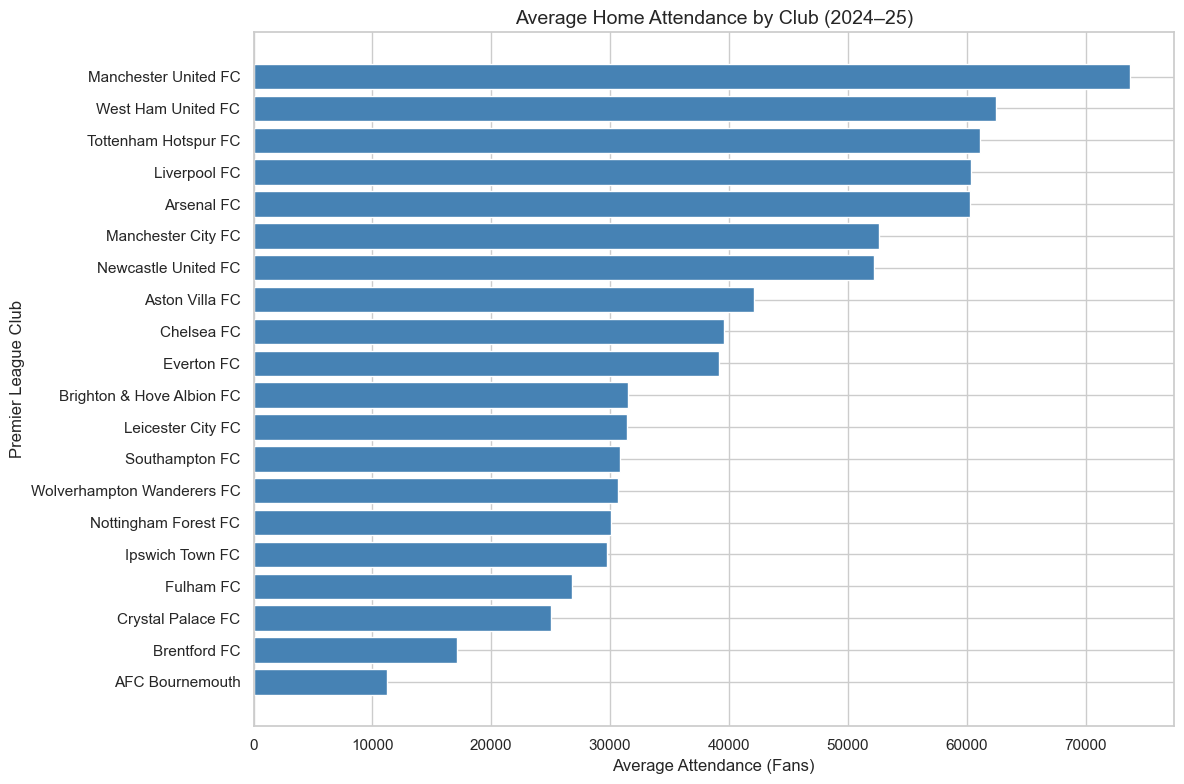

In [22]:
plt.figure(figsize=(12, 8))

sorted_df = merged_df.sort_values(
    "average_attendance",
    ascending=True
)

plt.barh(
    sorted_df["club"],
    sorted_df["average_attendance"],
    color="steelblue"
)

plt.title("Average Home Attendance by Club (2024–25)", fontsize=14)
plt.xlabel("Average Attendance (Fans)")
plt.ylabel("Premier League Club")

plt.tight_layout()
plt.savefig("attendance_by_club.png", dpi=300, bbox_inches="tight")
plt.show()

### Visualization 2: Fan Attendance vs League Points

This scatter plot examines the relationship between average home attendance and total league points.

Each dot represents one football club.

The regression line helps illustrate the direction of the relationship.

A positive trend would indicate that clubs with higher average attendance tend to earn more points.

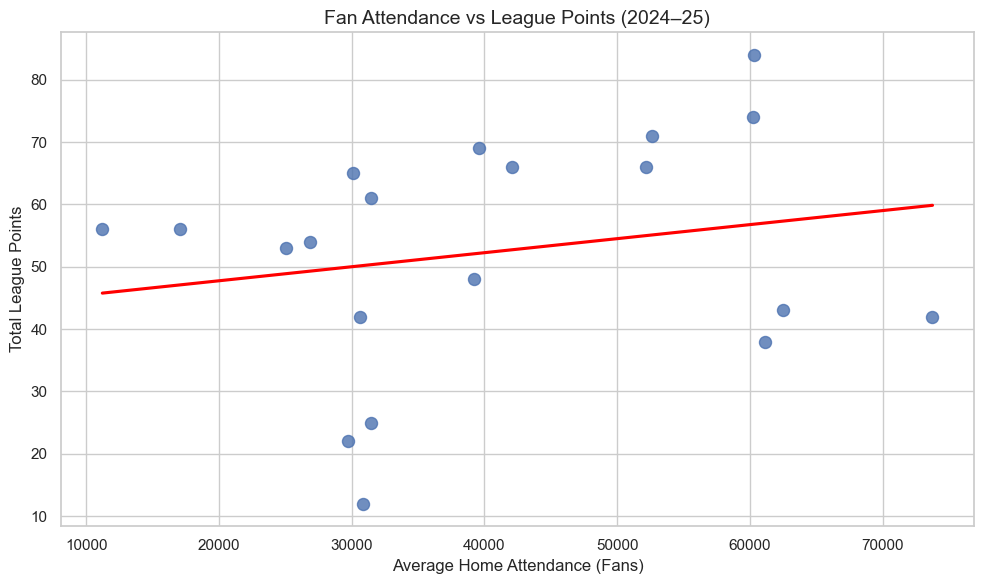

In [23]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=merged_df,
    x="average_attendance",
    y="total_points",
    scatter_kws={"s": 75, "alpha": 0.8},
    line_kws={"color": "red"},
    ci=None
)

plt.title("Fan Attendance vs League Points (2024–25)", fontsize=14)
plt.xlabel("Average Home Attendance (Fans)")
plt.ylabel("Total League Points")

plt.tight_layout()
plt.savefig("attendance_vs_points.png", dpi=300, bbox_inches="tight")
plt.show()

### Visualization 3: Fan Attendance vs Number of Wins

This scatter plot compares average home attendance with the number of matches won by each club.

The purpose is to investigate whether clubs with larger home crowds also achieve more victories during the season.

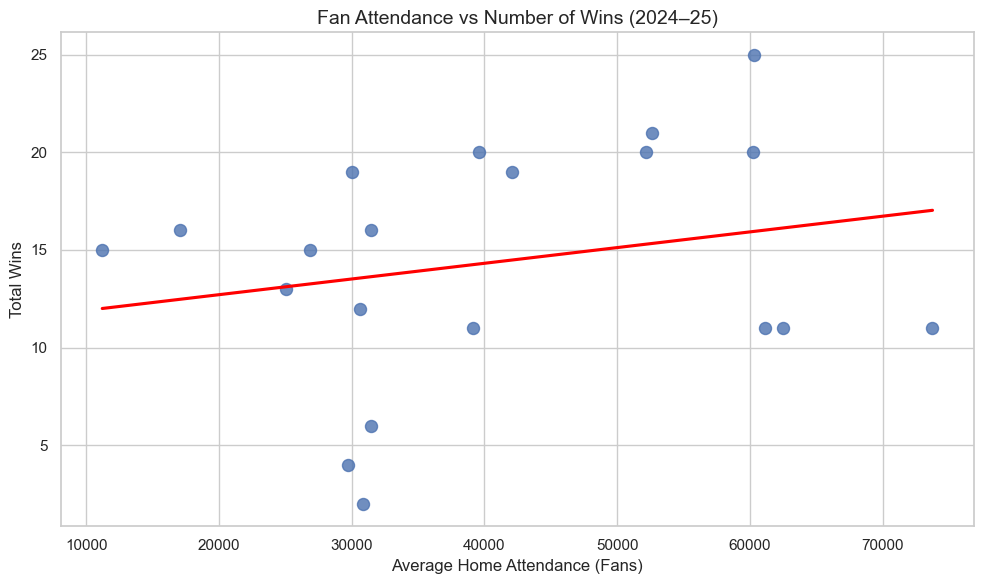

In [25]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=merged_df,
    x="average_attendance",
    y="wins",
    scatter_kws={"s": 75, "alpha": 0.8},
    line_kws={"color": "red"},
    ci=None
)

plt.title("Fan Attendance vs Number of Wins (2024–25)", fontsize=14)
plt.xlabel("Average Home Attendance (Fans)")
plt.ylabel("Total Wins")

plt.tight_layout()
plt.savefig("attendance_vs_wins.png", dpi=300, bbox_inches="tight")
plt.show()

### Visualization 4: Attendance vs League Position

This chart compares average attendance with final league position.

Since position 1 is the best result, the y-axis is inverted to display better positions at the top of the graph.

This visualization helps us understand whether attendance is associated with a club's league ranking.

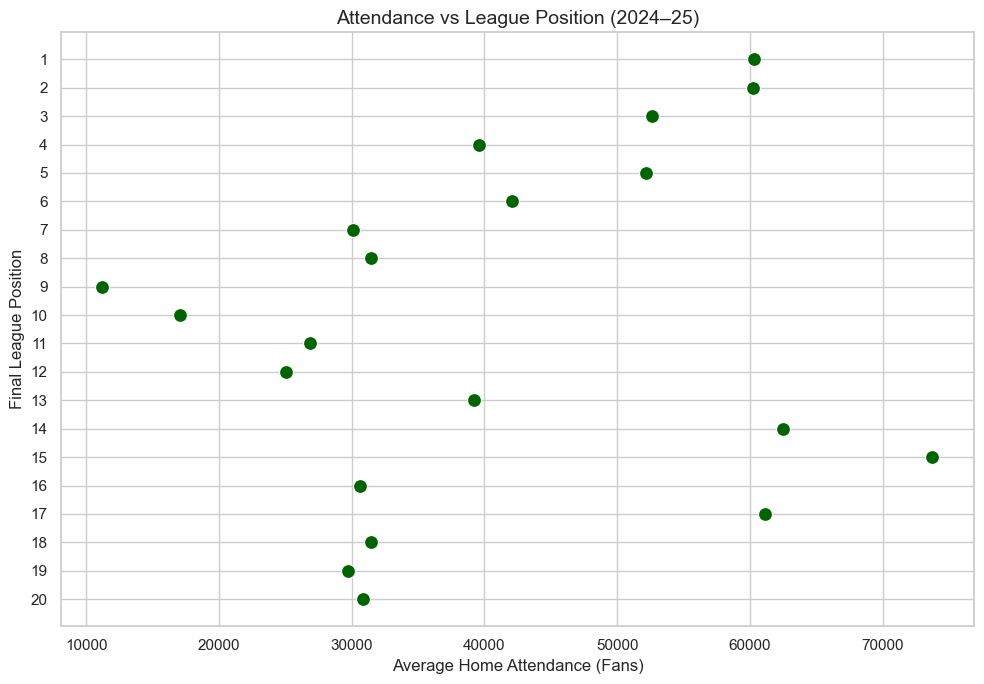

In [26]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=merged_df,
    x="average_attendance",
    y="league_position",
    s=100,
    color="darkgreen"
)

plt.title("Attendance vs League Position (2024–25)", fontsize=14)
plt.xlabel("Average Home Attendance (Fans)")
plt.ylabel("Final League Position")

plt.yticks(range(1, 21))
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("attendance_vs_position.png", dpi=300, bbox_inches="tight")
plt.show()

### Visualization 5: Correlation Heatmap

A correlation heatmap displays relationships between multiple numerical variables.

The colors and correlation coefficients help us identify positive and negative relationships between attendance, points, wins, losses, league position, and goal difference.

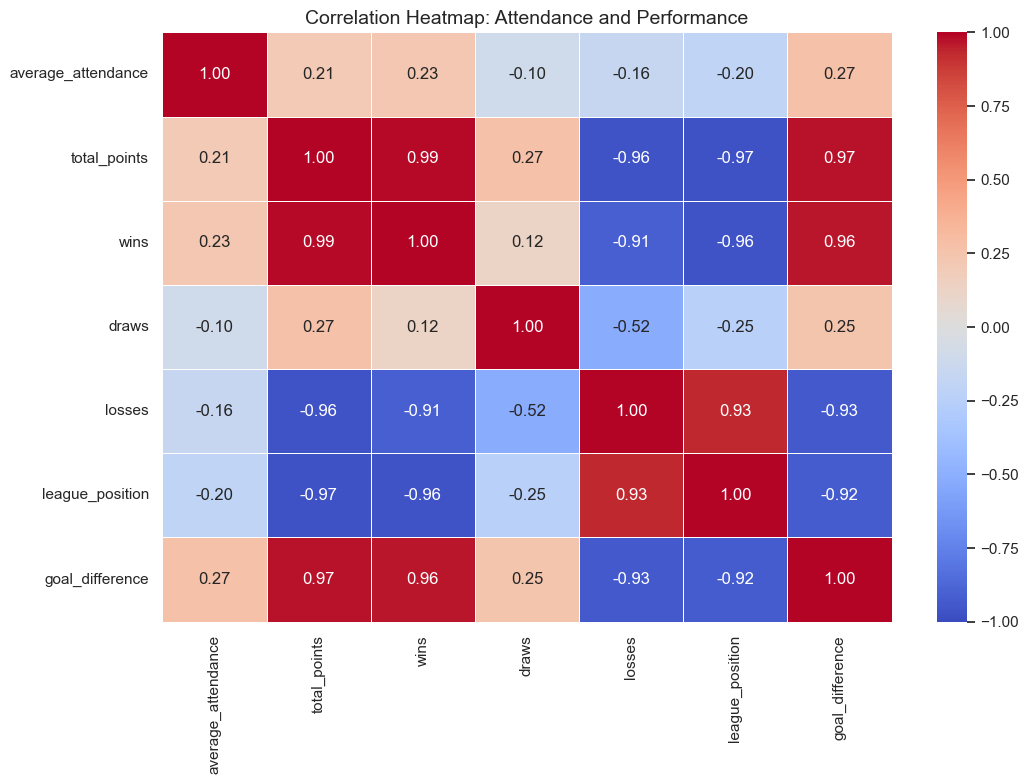

In [27]:
plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title("Correlation Heatmap: Attendance and Performance", fontsize=14)

plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Results and Discussion

The analysis was performed using data from 20 Premier League clubs during the 2024–2025 season.

### Attendance Statistics

The average home attendance across all clubs was approximately 40,401 fans.

Manchester United recorded the highest average attendance with 73,747 fans, while AFC Bournemouth had the lowest with 11,214 fans.

### Correlation Results

The Pearson correlation analysis produced the following results:

- Attendance vs Points: 0.206
- Attendance vs Wins: 0.228
- Attendance vs League Position: -0.197
- Attendance vs Goal Difference: 0.269

The results show a weak positive correlation between attendance and league points. A similar weak positive relationship was observed between attendance and the number of wins.

The relationship between attendance and league position was very weak and negative. Since lower position numbers represent better rankings, this suggests a slight tendency for clubs with larger crowds to finish higher.

### Interesting Findings

Manchester United had the highest attendance but finished in 15th place with only 42 points.

Liverpool had an average attendance of 60,330 fans and won the league with 84 points.

AFC Bournemouth had the lowest attendance but finished in 9th place with 56 points.

These examples show that higher attendance does not always correspond to better performance.

### Discussion

Overall, the correlations are weak. This suggests that attendance alone is not a strong indicator of football performance.

Other factors, such as squad quality, financial resources, management, and stadium capacity, may influence the observed relationships.

Correlation does not imply causation, so we cannot conclude that higher attendance directly improves football results.

In [28]:
def correlation_strength(value):
    value = abs(value)

    if value >= 0.7:
        return "strong"
    elif value >= 0.4:
        return "moderate"
    elif value >= 0.2:
        return "weak"
    else:
        return "very weak"


def correlation_direction(value):
    if value > 0:
        return "positive"
    elif value < 0:
        return "negative"
    else:
        return "no"


print("PROJECT RESULTS")
print("-" * 50)

print("Season: 2024–2025")
print("Number of clubs:", len(merged_df))

print("\nHighest average attendance:")
print(
    highest_attendance["club"],
    "-",
    int(highest_attendance["average_attendance"]),
    "fans"
)

print("\nLowest average attendance:")
print(
    lowest_attendance["club"],
    "-",
    int(lowest_attendance["average_attendance"]),
    "fans"
)

print("\nCORRELATION RESULTS")

for name, value in [
    ("Attendance vs Points", corr_points),
    ("Attendance vs Wins", corr_wins),
    ("Attendance vs Position", corr_position),
    ("Attendance vs Goal Difference", corr_goals)
]:
    print(
        f"{name}: {value:.3f} "
        f"({correlation_strength(value)} "
        f"{correlation_direction(value)} correlation)"
    )

print("\nInterpretation:")

if corr_points > 0.2:
    print(
        "Clubs with higher attendance generally tend "
        "to collect more league points."
    )
elif corr_points < -0.2:
    print(
        "Clubs with higher attendance generally tend "
        "to collect fewer league points."
    )
else:
    print(
        "There is little evidence of a linear relationship "
        "between attendance and league points."
    )

PROJECT RESULTS
--------------------------------------------------
Season: 2024–2025
Number of clubs: 20

Highest average attendance:
Manchester United FC - 73747 fans

Lowest average attendance:
AFC Bournemouth - 11214 fans

CORRELATION RESULTS
Attendance vs Points: 0.206 (weak positive correlation)
Attendance vs Wins: 0.228 (weak positive correlation)
Attendance vs Position: -0.197 (very weak negative correlation)
Attendance vs Goal Difference: 0.269 (weak positive correlation)

Interpretation:
Clubs with higher attendance generally tend to collect more league points.


## 10. Conclusion

This project successfully demonstrated the complete data collection and preparation pipeline using two different sources: Football-data.org API and Wikipedia web scraping.

We collected performance and attendance data for 20 Premier League clubs from the 2024–2025 season.

The datasets were cleaned, standardized, and merged using pandas. We then performed exploratory data analysis, calculated correlations, and created five visualizations.

### Main Findings

The analysis found a weak positive correlation (r = 0.206) between average home attendance and total league points.

Attendance also showed a weak positive correlation with wins (r = 0.228) and goal difference (r = 0.269).

These results suggest that clubs with higher attendance may perform slightly better on average, but the relationship is not strong.

Therefore, fan attendance alone cannot reliably explain a club's performance in the Premier League.

### Limitations

This study analyzes only one Premier League season and uses average attendance for each club rather than individual match attendance.

Other factors, including stadium capacity, squad quality, and club finances, were not included in the analysis.

The results show correlations but do not establish a cause-and-effect relationship.

### Future Improvements

Future research could analyze several seasons and include individual match attendance, stadium capacity, and home match results.

This would provide a more detailed understanding of the relationship between football attendance and team performance.

## 11. References

1. Football-data.org. (2026). Football-data.org API Documentation.  
   https://www.football-data.org/documentation/quickstart

2. Football-data.org. Premier League Standings API.  
   https://api.football-data.org/v4/competitions/PL/standings

3. Wikipedia contributors. 2024–25 Premier League.  
   https://en.wikipedia.org/wiki/2024%E2%80%9325_Premier_League

4. pandas Documentation.  
   https://pandas.pydata.org/docs/

5. Beautiful Soup Documentation.  
   https://www.crummy.com/software/BeautifulSoup/bs4/doc/

6. Matplotlib Documentation.  
   https://matplotlib.org/stable/

7. Seaborn Documentation.  
   https://seaborn.pydata.org/